# Immutable updates and indexing

Runnable locally on CPU or on a Cloud TPU VM.

- Predict the values returned by functional indexed set and add.
- Distinguish array-value semantics from Python name rebinding and compiler storage choices.
- Accumulate repeated-index contributions with an explicit integer reference.
- Choose a fixed-shape mask when output shape must remain stable.

You want to replace a few array entries, but JAX rejects the NumPy-style assignment. The key idea is small: describe the new array value, then keep the result. We’ll try replacement and addition, check that the original value is still available, and see what happens when an index appears more than once.

## The idea

An indexed update in JAX returns an array value. This makes the relationship between old and new state explicit: the caller chooses which result to keep. The programming model describes values; compiler decisions about physical memory reuse are a separate issue.

## Separate a new value from a new physical buffer

Start with $[2,4,6]$. Setting the middle entry to $10$ produces $[2,10,6]$. Adding $10$ at that position produces $[2,14,6]$. Both operations begin from the same original values; the second is not automatically applied to the result of the first.

Draw two arrows from the original array, one labeled set and one labeled add. If you want sequential updates, explicitly feed the first result into the second operation. This is the same state-flow idea we will use in optimization and recurrent loops.

Do not infer allocation cost from that drawing. A compiler may reuse storage when it can preserve the program's semantics. First verify old/new values and duplicate-index behavior for the operation you use, then measure memory behavior separately.

$$
C_{i,k} = \sum_{j=1}^{N} A_{i,j} B_{j,k} = \text{einsum}(\texttt{'ij,jk->ik'}, A, B)
$$

### Pause and reason

You call an indexed update but keep using the original variable. Why might later predictions be unchanged?

<details><summary>Compare your reasoning</summary>

The returned updated value was discarded. Assign or pass that result into the next computation; do not expect the original array value to mutate.

</details>

## A Python name and an array value are different

After `y = x.at[1].set(20)`, $x$ still denotes the original array and $y$ denotes the updated value. After `x = x.at[1].set(20)`, the Python name $x$ is rebound to the new value. That spelling does not retroactively change another name holding the original value.

Keep `original = x` before an update when you want a reference for tests. Comparing original and updated makes the semantics visible. Repeatedly inspecting only the newly rebound name can make a functional update look like mutation even though the old value still exists.

## Set replaces; add accumulates

Replacing an entry means its old value no longer contributes at that position in the result. Adding a contribution means the old value remains and the contribution is combined with it. Use set for a known replacement and add for a scatter-like accumulation.

Repeated indices need particular care. With add, contributions to the same index are accumulated; their floating-point order may not be guaranteed. With conflicting set values for the same index, do not assume a portable last-write-wins order. Choose unique indices when you need deterministic replacement semantics and test duplicate accumulation with exact small integers before studying floating-point ordering.

## Choose a mask when you want to keep the shape

Selecting $x$[$x$ > threshold] extracts a variable number of elements: its output length depends on values. A masked replacement, `jnp.where(x > threshold, x, 0)`, keeps the original shape. They are different calculations even if both are described casually as filtering.

A fixed-shape representation is useful for staged computation. Later lessons will explain why value-dependent output lengths can fail under jit. Decide whether downstream code expects compacted selected data or an array with masked entries before choosing the operation.

## Make the index domain part of the contract

Our examples use explicit in-bounds integer indices and ordinary slices. Indexing behavior at out-of-bounds positions is not a substitute for validating bad input. Negative indexing, duplicate indices, masks, and scatter modes all need deliberate interpretation in a real data pipeline.

A small update test should verify unchanged positions as well as changed positions. Testing only the new value at one index could miss an unintended broadcast across a slice or a mistaken axis in a matrix.

## Carry functional updates into training state

A model update is a larger version of the same idea: parameters and gradients produce new parameters. The caller retains or checkpoints state. Functional indexed operations let you describe a selective change without mutating an old array value.

This lesson prepares you to reason about optimizer and simulation state. It is separate from memory efficiency or a training algorithm; those require broader computations and measurements.

## Step 1: Set up imports and input tensors

Import the required JAX modules and define the initial inputs for immutable updates and indexing.

In [1]:
import jax.numpy as jnp
# Construct `x` via `jnp.array([1., 2., 3., 4.])`
x = jnp.array([1., 2., 3., 4.])

Establishing explicit input shapes and dtypes first makes the downstream transformation contract deterministic.

## Step 2: Apply the core JAX transformation

Write the core computation and transformation step over the initialized inputs.

In [2]:
y = x.at[1].set(20.)
# Construct `z` via `x.at[jnp.array([0, 2])].add(5.)`
z = x.at[jnp.array([0, 2])].add(5.)

This stage executes the primary numerical transformation and binds the intermediate outputs.

## Step 3: Verify shapes and numerical invariants

Check that the resulting arrays satisfy the expected shape, dtype, and numerical tolerances.

In [3]:
assert jnp.allclose(x, jnp.array([1.,2.,3.,4.]))
# Assert that `jnp.allclose(y, jnp.array([1.,20.,3.,4.]))`.
assert jnp.allclose(y, jnp.array([1.,20.,3.,4.]))
# Assert that `jnp.allclose(z, jnp.array([6.,2.,8.,4.]))`.
assert jnp.allclose(z, jnp.array([6.,2.,8.,4.]))

These assertions lock in the exact numerical contract before you run the full experiment and variations.

## Run the example

In [4]:
# Immutable updates and indexing: An indexed update in JAX returns an array value.
# Import jax.numpy for this computation.
import jax.numpy as jnp
# Construct `x` via `jnp.array([1., 2., 3., 4.])`
x = jnp.array([1., 2., 3., 4.])
# Compute `y` from `x.at[1].set(20.)`
y = x.at[1].set(20.)
# Construct `z` via `x.at[jnp.array([0, 2])].add(5.)`
z = x.at[jnp.array([0, 2])].add(5.)
# Print the observed values to compare against the expected result.
print("Original:", x)
# Print diagnostic summary of the computed outputs.
print("Set:", y)
# Print diagnostic summary of the computed outputs.
print("Add:", z)
# Assert that `jnp.allclose(x, jnp.array([1.,2.,3.,4.]))`.
assert jnp.allclose(x, jnp.array([1.,2.,3.,4.]))
# Assert that `jnp.allclose(y, jnp.array([1.,20.,3.,4.]))`.
assert jnp.allclose(y, jnp.array([1.,20.,3.,4.]))
# Assert that `jnp.allclose(z, jnp.array([6.,2.,8.,4.]))`.
assert jnp.allclose(z, jnp.array([6.,2.,8.,4.]))

Original: [1. 2. 3. 4.]
Set: [ 1. 20.  3.  4.]
Add: [6. 2. 8. 4.]


Expected: Original: $[1., 2., 3., 4.]$; Set: $[1., 20., 3., 4.]$; Add: $[6., 2., 8., 4.]$.

## An update returns a new array

Predict: Which cells change after set, and which after add?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: An update returns a new array
# Combine or mask array elements to form `visual_data`.
visual_data = {'kind': 'heatmap', 'values': jnp.stack([x, y, z]).tolist(), 'rows': ['original', 'set index 1', 'add at 0 and 2'], 'columns': ['0', '1', '2', '3'], 'unit': 'stored value'}

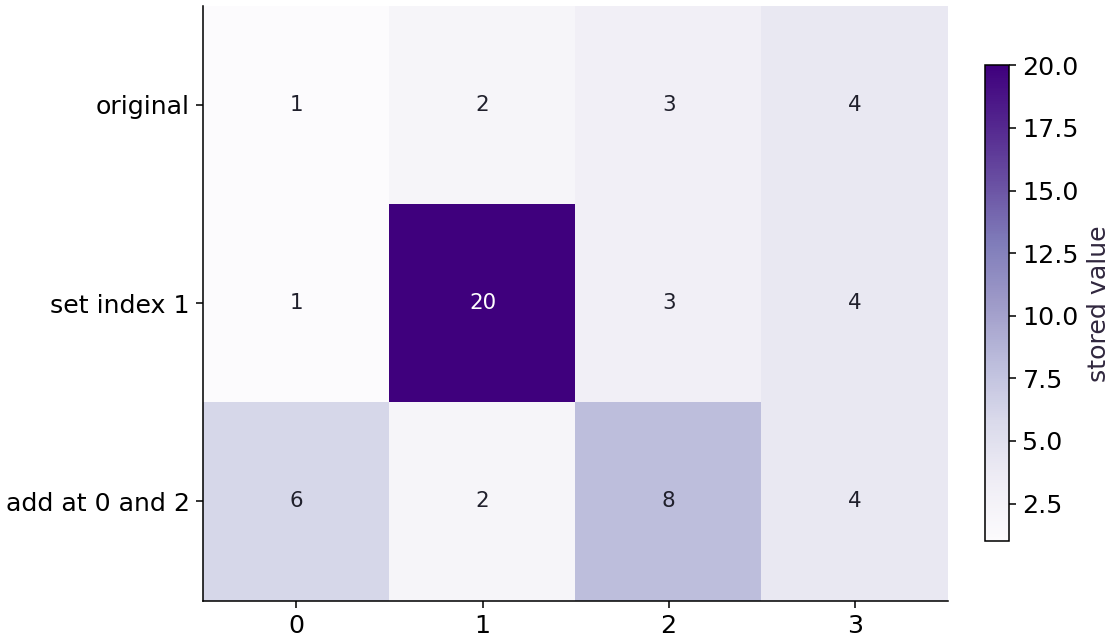

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Columns are array indices. The top row is the original array, and each lower row is a separate result created from that original. The cell colors encode stored values; the dark cell containing $20$ makes the replacement easy to locate.

The middle row replaces only index $1$: $(1,2,3,4)$ becomes $(1,20,3,4)$. The bottom row instead adds $5$ at indices $0$ and $2$, giving $(6,2,8,4)$.

### Connect it to the computation

The bottom row still contains $2$ at index $1$. This is the visual clue that the two updates branch from the original; the second operation did not continue from the middle row. In both cases, the top row remains unchanged.

An immutable update returns a new value. To make changes accumulate, pass the returned array into the next update. If these operations were chained, the final array would be $(6,20,8,4)$, which is deliberately not the bottom row shown here.

## See name rebinding without old-value mutation

Predict: If two names point at the original array and one name is rebound, which values remain available?

In [7]:
# Experiment — See name rebinding without old-value mutation: Assigning a result changes the binding, while ignoring a result...
original = x
# Compute `rebound` from `x`
rebound = x
# Compute `rebound` from `rebound.at[1].set(20.)`
rebound = rebound.at[1].set(20.)
# Assert that `jnp.allclose(original, jnp.array([1., 2., 3., 4.]))`.
assert jnp.allclose(original, jnp.array([1., 2., 3., 4.]))
# Assert that `jnp.allclose(rebound, jnp.array([1., 20., 3., 4.]))`.
assert jnp.allclose(rebound, jnp.array([1., 20., 3., 4.]))
# Compute `ignored` from `x.at[0].set(99.)`
ignored = x.at[0].set(99.)
# Assert that `jnp.allclose(x, original)`.
assert jnp.allclose(x, original)
# Assert invariant `float(ignored[0]) == 99.` holds
assert float(ignored[0]) == 99.

Expected: The original remains $[1, 2, 3, 4]$; rebound and ignored hold separate returned values.

Assigning a result changes the binding, while ignoring a result leaves the caller using the old value.

## Accumulate repeated integer contributions

Predict: Predict the total at index $1$ after adding contributions $2$ and $3$ there. What differs from replacement?

In [8]:
# Experiment — Accumulate repeated integer contributions: The integer loop reference makes accumulation explicit.
# Import numpy for this computation.
import numpy as np
# Construct `indices` via `jnp.array([1, 1, 3])`
indices = jnp.array([1, 1, 3])
# Construct `contributions` via `jnp.array([2, 3, 7], dtype=jnp.int32)`
contributions = jnp.array([2, 3, 7], dtype=jnp.int32)
# Construct `base_counts` via `jnp.zeros(4, dtype=jnp.int32)`
base_counts = jnp.zeros(4, dtype=jnp.int32)
# Compute `counts` from `base_counts.at[indices].add(contributions)`
counts = base_counts.at[indices].add(contributions)
# Allocate initialized array `reference_counts` with the specified shape and dtype.
reference_counts = np.zeros(4, dtype=np.int32)
# Iterate over `(index, contribution)` to step through the computation:
for index, contribution in zip([1, 1, 3], [2, 3, 7]):
    # Accumulate the next contribution into `reference_counts[index]`.
    reference_counts[index] += contribution
# Assert invariant `jnp.array_equal(counts, reference_counts)` holds
assert jnp.array_equal(counts, reference_counts)
# Assert invariant `jnp.array_equal(counts, jnp.array([0, 5, 0, 7]))` holds
assert jnp.array_equal(counts, jnp.array([0, 5, 0, 7]))
# Assert invariant `jnp.array_equal(base_counts, jnp.zeros(4, dtype=jnp.int32))` holds
assert jnp.array_equal(base_counts, jnp.zeros(4, dtype=jnp.int32))

Expected: The counts are $[0, 5, 0, 7]$; repeated index $1$ receives both contributions.

The integer loop reference makes accumulation explicit. It avoids asserting a floating-point reduction order or conflicting-set behavior.

## Your exercise

Replace the last two elements with zero in a new array. Keep $x$ unchanged.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Assert that `jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))`.
2. Assert that `jnp.allclose(x, jnp.array([1.,2.,3.,4.]))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Replace the last two elements with zero in a new array.
masked = ...  # TODO: compute masked
# Assert that `jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))`.
assert jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(x, jnp.array([1.,2.,3.,4.]))`.
assert jnp.allclose(x, jnp.array([1.,2.,3.,4.]))  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Replace the last two elements with zero in a new array.
# masked = ...  # TODO: compute masked
# Assert that `jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))`.
# assert jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(x, jnp.array([1.,2.,3.,4.]))`.
# assert jnp.allclose(x, jnp.array([1.,2.,3.,4.]))  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Replace the last two elements with zero in a new array.
masked = x.at[2:].set(0.)
# Assert that `jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))`.
assert jnp.allclose(masked, jnp.array([1.,2.,0.,0.]))
# Assert that `jnp.allclose(x, jnp.array([1.,2.,3.,4.]))`.
assert jnp.allclose(x, jnp.array([1.,2.,3.,4.]))

## Replace a region of a matrix · Practice

Create a $(3, 3)$ matrix containing $0$ through $8$. Set its final column to $-1$ in a returned value. Verify the whole result and original matrix.

Hint: The slice [:, $-1$] selects every row and the last column. A scalar replacement broadcasts across that slice.

### How to write: Replace a region of a matrix — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.arange(n, dtype=...)` — Creates a 1-D JAX array of evenly spaced values `[0, 1, ..., n-1]` on the target device.
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Construct and reshape `matrix` into the target tensor dimensions.
2. Compute `updated_matrix` from `matrix.at[:, -1].set(-1.)`
3. Assert that `jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))`.
4. Assert that `jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Replace a region of a matrix (Practice): Checking the entire matrix verifies both changed and...
# Construct and reshape `matrix` into the target tensor dimensions.
matrix = jnp.arange(...)  # TODO: compute matrix
# Compute `updated_matrix` from `matrix.at[:, -1].set(-1.)`
updated_matrix = ...  # TODO: compute updated_matrix
# Assert that `jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))`.
assert jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))  # TODO: complete assertion check
# Assert that `jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))`.
assert jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Replace a region of a matrix (Practice): Checking the entire matrix verifies both changed and...
# Construct and reshape `matrix` into the target tensor dimensions.
# matrix = jnp.arange(...)  # TODO: compute matrix
# Compute `updated_matrix` from `matrix.at[:, -1].set(-1.)`
# updated_matrix = ...  # TODO: compute updated_matrix
# Assert that `jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))`.
# assert jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))  # TODO: complete assertion check
# Assert that `jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))`.
# assert jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))  # TODO: complete assertion check

## Reference reasoning

Checking the entire matrix verifies both changed and unchanged positions; preserving the original checks the update contract.

In [12]:
# Replace a region of a matrix (Practice): Checking the entire matrix verifies both changed and...
# Construct and reshape `matrix` into the target tensor dimensions.
matrix = jnp.arange(9, dtype=jnp.float32).reshape(3, 3)
# Compute `updated_matrix` from `matrix.at[:, -1].set(-1.)`
updated_matrix = matrix.at[:, -1].set(-1.)
# Assert that `jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))`.
assert jnp.allclose(updated_matrix, jnp.array([[0., 1., -1.], [3., 4., -1.], [6., 7., -1.]]))
# Assert that `jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))`.
assert jnp.allclose(matrix, jnp.arange(9).reshape(3, 3))

## Keep shape while masking values · Challenge

Keep only values greater than $2$ from $x$, replacing other positions with zero. Compare with compact selection and explain the shape difference.

Hint: Use where for the fixed-shape result. Boolean indexing produces selected values, not a shape-preserving mask.

### How to write: Keep shape while masking values — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Compute `selected` from `x[x > 2.]`
2. Check tensor shape invariant: `fixed_shape.shape == (4,)`
3. Check tensor shape invariant: `selected.shape == (2,)`
4. Assert that `jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))`.
5. Assert that `jnp.allclose(selected, jnp.array([3., 4.]))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Keep shape while masking values (Challenge): Both are useful representations, but they are not...
fixed_shape = jnp.where(...)  # TODO: compute fixed_shape
# Compute `selected` from `x[x > 2.]`
selected = ...  # TODO: compute selected
# Check tensor shape invariant: `fixed_shape.shape == (4,)`
assert fixed_shape.shape  # TODO: complete assertion check
# Check tensor shape invariant: `selected.shape == (2,)`
assert selected.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))`.
assert jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(selected, jnp.array([3., 4.]))`.
assert jnp.allclose(selected, jnp.array([3., 4.]))  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Keep shape while masking values (Challenge): Both are useful representations, but they are not...
# fixed_shape = jnp.where(...)  # TODO: compute fixed_shape
# Compute `selected` from `x[x > 2.]`
# selected = ...  # TODO: compute selected
# Check tensor shape invariant: `fixed_shape.shape == (4,)`
# assert fixed_shape.shape  # TODO: complete assertion check
# Check tensor shape invariant: `selected.shape == (2,)`
# assert selected.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))`.
# assert jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(selected, jnp.array([3., 4.]))`.
# assert jnp.allclose(selected, jnp.array([3., 4.]))  # TODO: complete assertion check

## Reference reasoning

Both are useful representations, but they are not interchangeable. The expected downstream shape determines which is appropriate.

In [14]:
# Keep shape while masking values (Challenge): Both are useful representations, but they are not...
fixed_shape = jnp.where(x > 2., x, 0.)
# Compute `selected` from `x[x > 2.]`
selected = x[x > 2.]
# Check tensor shape invariant: `fixed_shape.shape == (4,)`
assert fixed_shape.shape == (4,)
# Check tensor shape invariant: `selected.shape == (2,)`
assert selected.shape == (2,)
# Assert that `jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))`.
assert jnp.allclose(fixed_shape, jnp.array([0., 0., 3., 4.]))
# Assert that `jnp.allclose(selected, jnp.array([3., 4.]))`.
assert jnp.allclose(selected, jnp.array([3., 4.]))

## Checkpoint

After `y = x.at[1].set(20.)`, what happens to $x$?

1. Its second element becomes $20$
2. Its value remains unchanged
3. It becomes a Python list

## Diagnose

If nothing changes, check whether the returned update was discarded. If old values seem changed, distinguish name rebinding from mutation and inspect mutable containers around the array. If duplicate replacements are surprising, do not assume last-write-wins order; use an explicit unique-index policy. If a mask later fails under jit, inspect whether its output length depends on runtime values.

## Evidence

Keep original and updated arrays, a repeated-index integer reference, the whole-matrix replacement check, and compact-versus-fixed-shape outputs. Explain replacement, accumulation, and name rebinding.

## Carry forward

- Indexed updates return values; retaining them is the caller’s responsibility.
- Name rebinding and mutation are different operations.
- Repeated-index add accumulates contributions, while conflicting set needs a deliberate policy.
- A shape-preserving mask and compact selection express different computations.

## Primary references

- [JAX: indexed update API](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html)
- [JAX: immutability and array updates](https://docs.jax.dev/en/latest/notebooks/Common_Gotchas_in_JAX.html#in-place-updates)